In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

adidas = yf.download("ADS.DE", start="2022-06-01", end="2023-03-01")
adidas.head()


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,ADS.DE,ADS.DE,ADS.DE,ADS.DE,ADS.DE
Date,,,,,
2022-06-01,179.469620,183.365137,178.800683,182.932313,536496
2022-06-02,179.469620,179.469620,179.469620,179.469620,0
2022-06-03,179.469620,179.469620,179.469620,179.469620,0
2022-06-06,185.273544,187.004899,183.699604,185.903124,364755
2022-06-07,182.971634,184.034052,179.587640,183.306095,582973


In [9]:
event = pd.to_datetime("2022-10-25")  # Kanye-Yeezy split

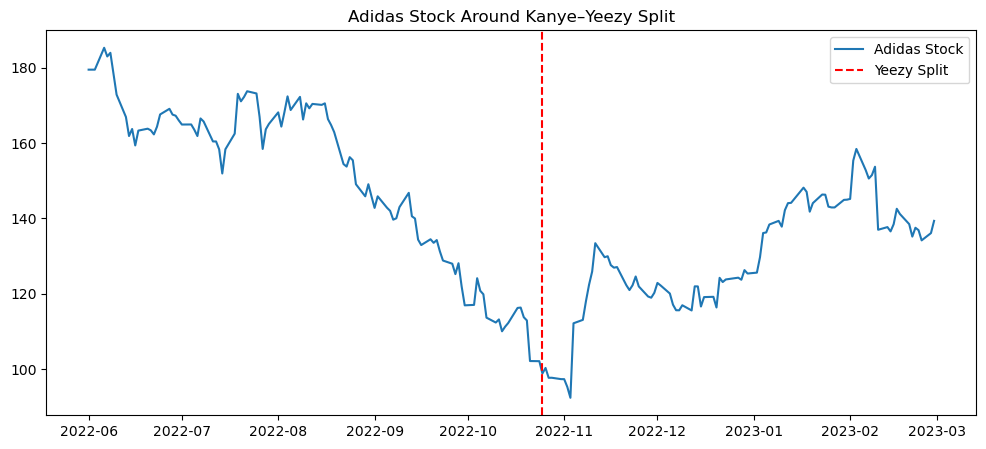

In [10]:
plt.figure(figsize=(12,5))

plt.plot(adidas.index, adidas["Close"], label="Adidas Stock")
plt.axvline(event, color="red", linestyle="--", label="Yeezy Split")

plt.legend()
plt.title("Adidas Stock Around Kanye–Yeezy Split")
plt.show()

In [11]:
adidas["Close_norm"] = adidas["Close"] / adidas["Close"].max()

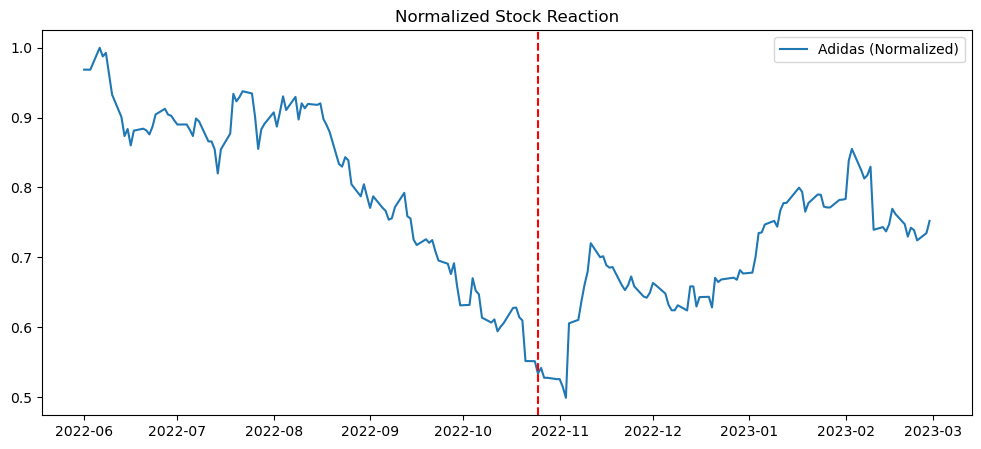

In [12]:
plt.figure(figsize=(12,5))

plt.plot(adidas.index, adidas["Close_norm"], label="Adidas (Normalized)")
plt.axvline(event, color="red", linestyle="--")

plt.legend()
plt.title("Normalized Stock Reaction")
plt.show()

In [13]:
from scipy.stats import ttest_ind

before = adidas[adidas.index < event]["Close"]
after = adidas[adidas.index >= event]["Close"]

t_stat, p_value = ttest_ind(before, after, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: [8.33281546]
P-value: [1.79375079e-14]


In [14]:
import pandas as pd

kanye = pd.read_csv("/Users/kaanadaleti/Desktop/dsa_proje/adidas_kanye_yeezy_trends.csv")

kanye.head()

,Time,Kanye West,ADIDAS,Yeezy
0,2022-08-31,6,45,1
1,2022-09-01,7,43,1
2,2022-09-02,12,44,1
3,2022-09-03,12,50,1
4,2022-09-04,13,53,1


In [21]:
kanye = kanye[["Time", "Kanye West"]]

In [16]:
kanye["Time"] = pd.to_datetime(kanye["Time"])
kanye = kanye.sort_values("Time")

In [19]:
adidas = yf.download("ADS.DE", start="2022-06-01", end="2023-03-01", group_by="column")
adidas = adidas.reset_index()

[*********************100%***********************]  1 of 1 completed


In [23]:
import yfinance as yf
import pandas as pd

adidas = yf.download("ADS.DE", start="2022-06-01", end="2023-03-01")

adidas = adidas.reset_index()

[*********************100%***********************]  1 of 1 completed


In [24]:
adidas.columns = adidas.columns.to_flat_index()
adidas.columns = [str(col) for col in adidas.columns]

In [25]:
print(adidas.columns)
adidas.head()

Index(['('Date', '')', '('Close', 'ADS.DE')', '('High', 'ADS.DE')',
       '('Low', 'ADS.DE')', '('Open', 'ADS.DE')', '('Volume', 'ADS.DE')'],
      dtype='object')


,"('Date', '')","('Close', 'ADS.DE')","('High', 'ADS.DE')","('Low', 'ADS.DE')","('Open', 'ADS.DE')","('Volume', 'ADS.DE')"
0,2022-06-01,179.469620,183.365137,178.800683,182.932313,536496
1,2022-06-02,179.469620,179.469620,179.469620,179.469620,0
2,2022-06-03,179.469620,179.469620,179.469620,179.469620,0
3,2022-06-06,185.273544,187.004899,183.699604,185.903124,364755
4,2022-06-07,182.971634,184.034052,179.587640,183.306095,582973


In [27]:
adidas.columns

Index(['('Date', '')', '('Close', 'ADS.DE')', '('High', 'ADS.DE')',
       '('Low', 'ADS.DE')', '('Open', 'ADS.DE')', '('Volume', 'ADS.DE')'],
      dtype='object')

In [28]:
import yfinance as yf
import pandas as pd

adidas = yf.download("ADS.DE", start="2022-06-01", end="2023-03-01")

[*********************100%***********************]  1 of 1 completed


In [29]:
adidas = adidas.reset_index()

In [30]:
adidas.columns = [col[0] if isinstance(col, tuple) else col for col in adidas.columns]

In [31]:
print(adidas.columns)
adidas.head()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


,Date,Close,High,Low,Open,Volume
0,2022-06-01,179.469620,183.365137,178.800683,182.932313,536496
1,2022-06-02,179.469620,179.469620,179.469620,179.469620,0
2,2022-06-03,179.469620,179.469620,179.469620,179.469620,0
3,2022-06-06,185.273544,187.004899,183.699604,185.903124,364755
4,2022-06-07,182.971634,184.034052,179.587640,183.306095,582973


In [32]:
merged = pd.merge(kanye, adidas, left_on="Time", right_on="Date")

In [33]:
merged = pd.merge(kanye, adidas, left_on="Time", right_on="Date")

In [34]:
print(merged.head())

        Time  Kanye West       Date       Close        High         Low  \
0 2022-08-31           6 2022-08-31  145.865784  150.135119  145.688722   
1 2022-09-01           7 2022-09-01  142.796570  144.626287  141.320992   
2 2022-09-02          12 2022-09-02  145.865784  146.692104  141.025890   
3 2022-09-05           9 2022-09-05  142.835922  143.681921  140.120865   
4 2022-09-06           8 2022-09-06  142.009613  144.350868  140.376637   

         Open  Volume  
0  149.899036  648649  
1  144.311490  631030  
2  144.823044  618112  
3  141.714484  539463  
4  140.494693  490248  


In [35]:
merged["K_norm"] = merged["Kanye West"] / merged["Kanye West"].max()
merged["S_norm"] = merged["Close"] / merged["Close"].max()

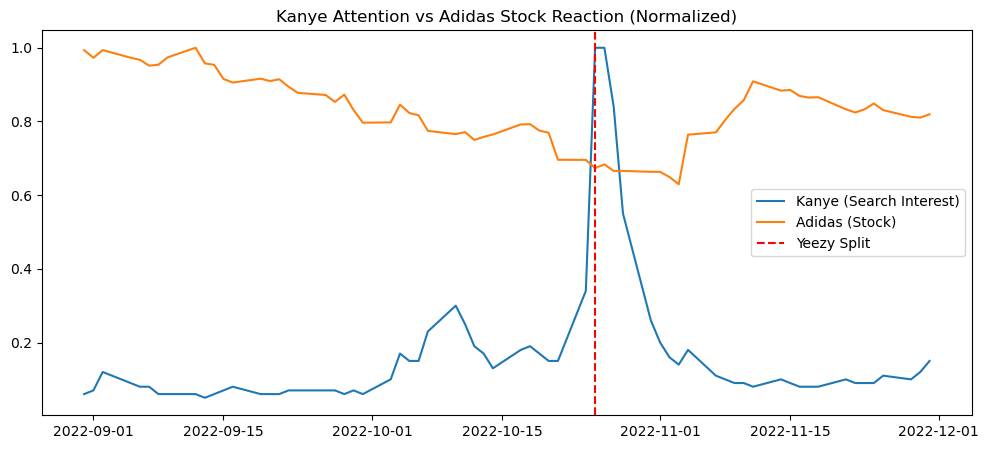

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(merged["Time"], merged["K_norm"], label="Kanye (Search Interest)")
plt.plot(merged["Time"], merged["S_norm"], label="Adidas (Stock)")

event = pd.to_datetime("2022-10-25")
plt.axvline(event, color="red", linestyle="--", label="Yeezy Split")

plt.legend()
plt.title("Kanye Attention vs Adidas Stock Reaction (Normalized)")
plt.show()

In [37]:
from scipy.stats import ttest_ind

before = merged[merged["Time"] < event]["Close"]
after = merged[merged["Time"] >= event]["Close"]

t_stat, p_value = ttest_ind(before, after, equal_var=False)

print("T-stat:", t_stat)
print("P-value:", p_value)

T-stat: 3.460834244978824
P-value: 0.0010322460047400704
